<a href="https://colab.research.google.com/github/Subhash-2910/flyrank-ML-T1/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Subhash-2910/flyrank-ML-T1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [8]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Subhash-2910/flyrank-ML-T1.git"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
            check=True
        )
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
        check=True
    )
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv")
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*



This playbook ranks pages for **human content review**. It does not automatically rewrite, remove, merge, publish, or change any page.

The ranking uses the Week-6 grouped-validation model. It estimates an observed downward-trend risk from stable content and market signals.

Actions:

- `REVIEW_FOR_REFRESH` — a high-priority candidate for a human refresh review.
- `MONITOR` — keep observing; no immediate refresh recommendation.
- `NO_AUTOMATIC_CHANGE` — a model score alone never authorizes an automatic content change.

Reason codes:

- `STALE_HIGH_DEMAND` — an older page with meaningful search demand.
- `STALE_THIN_CONTENT` — an older page with relatively low content depth.
- `DECLINE_RISK_REVIEW` — a higher model score without either specific archetype.
- `LOWER_PRIORITY_MONITOR` — lower model score; monitor rather than act now.

The decay/refresh insight is directional: pages that are old and still have search demand may be useful candidates for review, but age or demand alone does not show that a refresh will improve performance.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os
import json
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

id_col = "content_id"
group_col = "client_id"
target_col = "decline_label"

# Observed outcome used only for retrospective model training/evaluation.
df[target_col] = (df["trend_direction"] == "down").astype(int)

# Stable, non-outcome-window features retained after the Week-6 leakage audit.
numeric_features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update",
]

categorical_features = [
    "competition_level",
    "content_type",
    "main_intent",
]

feature_cols = numeric_features + categorical_features

model_df = df[[id_col, group_col, target_col] + feature_cols].copy()

preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        numeric_features,
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]),
        categorical_features,
    ),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    )),
])

# Grouped split: score only held-out clients.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

train_idx, test_idx = next(
    splitter.split(
        model_df,
        y=model_df[target_col],
        groups=model_df[group_col],
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

assert set(train_df[group_col]).isdisjoint(set(test_df[group_col]))

model.fit(train_df[feature_cols], train_df[target_col])

playbook = df.loc[test_df.index, [
    id_col,
    group_col,
    "search_volume",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "content_type",
    "main_intent",
]].copy()

playbook["model_decline_score"] = model.predict_proba(
    test_df[feature_cols]
)[:, 1]

# Transparent thresholds used only to create reason codes.
stale_cutoff = df["days_since_last_update"].quantile(0.75)
demand_cutoff = df["search_volume"].quantile(0.75)
thin_content_cutoff = df["word_count"].quantile(0.25)
high_score_cutoff = playbook["model_decline_score"].quantile(0.75)

playbook["reason_code"] = np.select(
    [
        (
            (playbook["days_since_last_update"] >= stale_cutoff)
            & (playbook["search_volume"] >= demand_cutoff)
        ),
        (
            (playbook["days_since_last_update"] >= stale_cutoff)
            & (playbook["word_count"] <= thin_content_cutoff)
        ),
        playbook["model_decline_score"] >= high_score_cutoff,
    ],
    [
        "STALE_HIGH_DEMAND",
        "STALE_THIN_CONTENT",
        "DECLINE_RISK_REVIEW",
    ],
    default="LOWER_PRIORITY_MONITOR",
)

playbook["action_label"] = np.where(
    playbook["reason_code"] == "LOWER_PRIORITY_MONITOR",
    "MONITOR",
    "REVIEW_FOR_REFRESH",
)

playbook["human_review_required"] = "YES"

playbook["review_note"] = np.where(
    playbook["action_label"] == "REVIEW_FOR_REFRESH",
    "Review search intent, accuracy, freshness, competition, and editorial value before any change.",
    "Monitor performance; do not make an automatic content change."
)

playbook = playbook.sort_values(
    by=["action_label", "model_decline_score"],
    ascending=[True, False],
).reset_index(drop=True)

display(playbook.head(20))

,content_id,client_id,search_volume,word_count,content_age_days,days_since_last_update,content_type,main_intent,model_decline_score,reason_code,action_label,human_review_required,review_note
0,content_1f1c6b273a44,client_f369cb89fc,0.0,2962.0,131,20,keyword article,informational,0.587632,LOWER_PRIORITY_MONITOR,MONITOR,YES,Monitor performance; do not make an automatic ...
1,content_405cbd1b3550,client_f369cb89fc,0.0,2780.0,117,8,keyword article,informational,0.587631,LOWER_PRIORITY_MONITOR,MONITOR,YES,Monitor performance; do not make an automatic ...
2,content_fb1443847c2e,client_f369cb89fc,0.0,2751.0,126,20,keyword article,informational,0.587609,LOWER_PRIORITY_MONITOR,MONITOR,YES,Monitor performance; do not make an automatic ...
3,content_6fb7e84bfcbb,client_f369cb89fc,0.0,2846.0,141,8,keyword article,informational,0.587537,LOWER_PRIORITY_MONITOR,MONITOR,YES,Monitor performance; do not make an automatic ...
4,content_4bc9157109f4,client_f369cb89fc,0.0,2711.0,141,8,keyword article,informational,0.587534,LOWER_PRIORITY_MONITOR,MONITOR,YES,Monitor performance; do not make an automatic ...
5,content_1e14ade1f5c3,client_f369cb89fc,10.0,2687.0,97,20,keyword article,commercial,0.587531,LOWER_PRIORITY_MONITOR,MONITOR,YES,Monitor performance; do not make an automatic ...
6,content_0ca85d2f49be,client_f369cb89fc,0.0,2948.0,126,20,keyword article,informational,0.587527,LOWER_PRIORITY_MONITOR,MONITOR,YES,Monitor performance; do not make an automatic ...
7,content_21670f9b7917,client_f369cb89fc,0.0,3000.0,131,20,keyword article,informational,0.587492,LOWER_PRIORITY_MONITOR,MONITOR,YES,Monitor performance; do not make an automatic ...
8,content_f6c21596a9d7,client_f369cb89fc,0.0,2702.0,131,20,keyword article,informational,0.587490,LOWER_PRIORITY_MONITOR,MONITOR,YES,Monitor performance; do not make an automatic ...
9,content_32097c1cfc4e,client_f369cb89fc,0.0,3034.0,131,20,keyword article,informational,0.587459,LOWER_PRIORITY_MONITOR,MONITOR,YES,Monitor performance; do not make an automatic ...


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*



## Intended use

This playbook helps a content or SEO team decide which pages to inspect first when review capacity is limited. The ranked queue is decision support for a human reviewer.

## Limits

The score is not a prediction of Google’s algorithm and not a guarantee that refreshing a page will improve performance.

A page can look stale or risky because of seasonality, changing search intent, competition, client strategy, or missing context. The model was evaluated on pseudonymized starter data and should not be treated as a production decision system.

The playbook measures observed patterns in this dataset. It does not establish that content changes cause future performance gains.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one
action_summary = (
    playbook.groupby(["action_label", "reason_code"], as_index=False)
    .agg(
        pages=(id_col, "size"),
        average_model_score=("model_decline_score", "mean"),
        median_days_since_update=("days_since_last_update", "median"),
        median_search_volume=("search_volume", "median"),
    )
    .sort_values(["action_label", "pages"], ascending=[True, False])
)

display(action_summary.round(3))

print("Total pages in held-out playbook:", len(playbook))
print(
    "Pages recommended for human refresh review:",
    (playbook["action_label"] == "REVIEW_FOR_REFRESH").sum()
)

,action_label,reason_code,pages,average_model_score,median_days_since_update,median_search_volume
0,MONITOR,LOWER_PRIORITY_MONITOR,4034,0.428,20.0,10.0
1,REVIEW_FOR_REFRESH,DECLINE_RISK_REVIEW,1414,0.613,20.0,0.0
2,REVIEW_FOR_REFRESH,STALE_HIGH_DEMAND,512,0.505,104.0,70.0
3,REVIEW_FOR_REFRESH,STALE_THIN_CONTENT,203,0.557,104.0,10.0


Total pages in held-out playbook: 6163
Pages recommended for human refresh review: 2129


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



Every `REVIEW_FOR_REFRESH` recommendation requires human review before action.

A reviewer should check:

1. Whether the page still matches current search intent.
2. Whether factual content is outdated or incomplete.
3. Whether the page has editorial, legal, brand, or conversion value.
4. Whether seasonal patterns explain the observed performance.
5. Whether technical SEO, indexing, or competition explains the issue better than content quality.

## What must not be automated

This playbook must not automatically:

- rewrite, publish, delete, merge, or prune content;
- change titles, metadata, or URLs;
- make claims about causal refresh impact;
- use client IDs, content IDs, private URLs, or private queries as features;
- make decisions about high-risk, legal, medical, financial, or brand-sensitive content without human approval.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

review_queue = playbook.loc[
    playbook["action_label"] == "REVIEW_FOR_REFRESH"
].copy()

review_queue["review_checklist"] = (
    "Check intent; verify accuracy; assess freshness; inspect competition; "
    "confirm editorial and business value."
)

display(
    review_queue[
        [
            id_col,
            "action_label",
            "reason_code",
            "model_decline_score",
            "review_note",
            "review_checklist",
        ]
    ].head(20)
)

print("Human review is required for every action recommendation.")
print("No content change is automated by this notebook.")

,content_id,action_label,reason_code,model_decline_score,review_note,review_checklist
4034,content_b925c292d21b,REVIEW_FOR_REFRESH,DECLINE_RISK_REVIEW,0.706687,"Review search intent, accuracy, freshness, com...",Check intent; verify accuracy; assess freshnes...
4035,content_e5b7ee456c43,REVIEW_FOR_REFRESH,DECLINE_RISK_REVIEW,0.705162,"Review search intent, accuracy, freshness, com...",Check intent; verify accuracy; assess freshnes...
4036,content_6ac3ab740bbf,REVIEW_FOR_REFRESH,DECLINE_RISK_REVIEW,0.704606,"Review search intent, accuracy, freshness, com...",Check intent; verify accuracy; assess freshnes...
4037,content_a5dbb404bdc2,REVIEW_FOR_REFRESH,DECLINE_RISK_REVIEW,0.704164,"Review search intent, accuracy, freshness, com...",Check intent; verify accuracy; assess freshnes...
4038,content_c65ee459f729,REVIEW_FOR_REFRESH,DECLINE_RISK_REVIEW,0.703701,"Review search intent, accuracy, freshness, com...",Check intent; verify accuracy; assess freshnes...
4039,content_829c68e60d13,REVIEW_FOR_REFRESH,DECLINE_RISK_REVIEW,0.702326,"Review search intent, accuracy, freshness, com...",Check intent; verify accuracy; assess freshnes...
4040,content_b08562686d22,REVIEW_FOR_REFRESH,DECLINE_RISK_REVIEW,0.702154,"Review search intent, accuracy, freshness, com...",Check intent; verify accuracy; assess freshnes...
4041,content_0ea80678706d,REVIEW_FOR_REFRESH,DECLINE_RISK_REVIEW,0.701394,"Review search intent, accuracy, freshness, com...",Check intent; verify accuracy; assess freshnes...
4042,content_26d48a980581,REVIEW_FOR_REFRESH,DECLINE_RISK_REVIEW,0.697199,"Review search intent, accuracy, freshness, com...",Check intent; verify accuracy; assess freshnes...
4043,content_94feac677ec4,REVIEW_FOR_REFRESH,STALE_THIN_CONTENT,0.696458,"Review search intent, accuracy, freshness, com...",Check intent; verify accuracy; assess freshnes...


Human review is required for every action recommendation.
No content change is automated by this notebook.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



This is a non-production, educational playbook. If it were used repeatedly, it should be monitored and reviewed before reuse.

Review or retrain the model when:

- Precision@20 materially declines on a new held-out evaluation period.
- The proportion of pages receiving `REVIEW_FOR_REFRESH` changes sharply.
- Content types, client mix, search demand, or intent distribution shifts.
- New features are introduced or the outcome definition changes.
- Human reviewers repeatedly identify weak or misleading recommendations.

Human reviewer feedback should be recorded as evidence for future evaluation, not silently converted into labels without a clear definition and time window.

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

monitoring_snapshot = {
    "playbook_rows": int(len(playbook)),
    "review_for_refresh_rows": int(
        (playbook["action_label"] == "REVIEW_FOR_REFRESH").sum()
    ),
    "review_for_refresh_share": round(
        float((playbook["action_label"] == "REVIEW_FOR_REFRESH").mean()),
        4
    ),
    "average_model_decline_score": round(
        float(playbook["model_decline_score"].mean()),
        4
    ),
    "grouped_test_clients": int(test_df[group_col].nunique()),
    "retrain_trigger": (
        "Review model performance and feature definitions when data mix, "
        "outcome definition, or measured Precision@20 changes materially."
    ),
}

display(pd.DataFrame([monitoring_snapshot]))

,playbook_rows,review_for_refresh_rows,review_for_refresh_share,average_model_decline_score,grouped_test_clients,retrain_trigger
0,6163,2129,0.3454,0.4811,7,Review model performance and feature definitio...


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*



This notebook exports:

- A ranked action queue for the deployed paper.
- A small action-summary figure for reuse in the paper.
- A JSON metrics receipt describing this run.

The CSV contains only pseudonymized identifiers and public-safe aggregated signals. It does not contain client names, domains, URLs, private queries, or credentials.

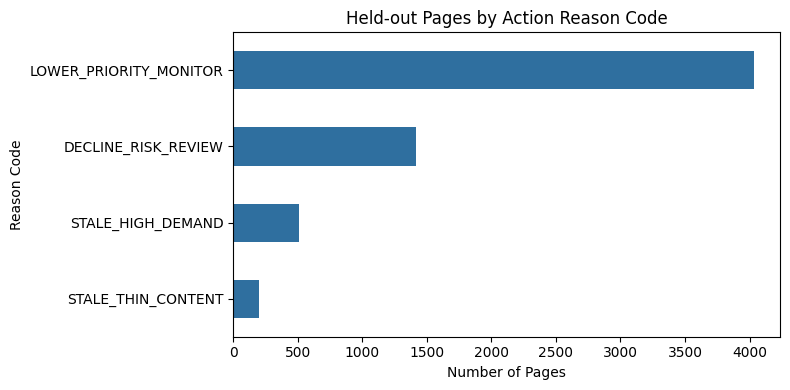

Queue exported to: work/outputs/ranked_action_playbook.csv
Metrics exported to: work/outputs/action_playbook_metrics.json
Figure exported to: work/figures/action_playbook_reason_codes.png


In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Public-safe queue for the paper. IDs are pseudonymized.
export_columns = [
    id_col,
    "search_volume",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "content_type",
    "main_intent",
    "model_decline_score",
    "reason_code",
    "action_label",
    "human_review_required",
    "review_note",
]

queue_path = "work/outputs/ranked_action_playbook.csv"
playbook[export_columns].to_csv(queue_path, index=False)

metrics_path = "work/outputs/action_playbook_metrics.json"
with open(metrics_path, "w") as file:
    json.dump(monitoring_snapshot, file, indent=2)

figure_data = (
    playbook["reason_code"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4))
figure_data.plot(kind="barh", color="#2f6f9f")
plt.title("Held-out Pages by Action Reason Code")
plt.xlabel("Number of Pages")
plt.ylabel("Reason Code")
plt.tight_layout()

figure_path = "work/figures/action_playbook_reason_codes.png"
plt.savefig(figure_path, dpi=160)
plt.show()

print("Queue exported to:", queue_path)
print("Metrics exported to:", metrics_path)
print("Figure exported to:", figure_path)

In [15]:
import os

for path in [
    "work/outputs/ranked_action_playbook.csv",
    "work/outputs/action_playbook_metrics.json",
    "work/figures/action_playbook_reason_codes.png",
]:
    print(path, "→", "FOUND" if os.path.exists(path) else "MISSING")

work/outputs/ranked_action_playbook.csv → FOUND
work/outputs/action_playbook_metrics.json → FOUND
work/figures/action_playbook_reason_codes.png → FOUND


In [14]:
assert os.path.exists("work/outputs/ranked_action_playbook.csv")
assert os.path.exists("work/outputs/action_playbook_metrics.json")
assert os.path.exists("work/figures/action_playbook_reason_codes.png")

print("Self-check passed.")
print("All paper-ready exports were created.")

Self-check passed.
All paper-ready exports were created.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.